# Study 3.1 — Detecting and dating the regime shifts

**Companion to Studies 2 & 3 — turning the qualitative "regime change" story into dated, certified evidence.**

Study 3 showed *descriptively* that the OAT pricing-noise floor stepped up after 2022 and that COVID was a distinct dislocation; Study 2 showed the 2022–24 inversion. Here we put **dates and statistical confidence** on those shifts using **peer-reviewed structural-change methods on our own structured price/yield series** — no unstructured/text data:

1. **Markov-switching (Hamilton, 1989)** — latent calm/elevated/crisis regimes and the smoothed probability of each through time, with transition probabilities and expected durations.
2. **Bai–Perron multiple structural breaks** — exact dating of the level shifts, number of breaks chosen by BIC.
3. **CUSUM stability test (Ploberger–Krämer)** — a formal test that each series is *not* structurally stable.

We apply the same toolkit to the **noise** (Study 3 dislocation), the **slope** 10y−2y (Study 2 inversion) and the **idiosyncratic OAT–Bund premium** (Study 1.1 political regime).

> *On the motivating paper.* Yi, Mehra, Chen & Cartlidge (2026) *enhance* regime-shift detection on the US Treasury market with **unstructured** (text) data. We deliberately do **not** reproduce that pipeline — no euro-area news corpus, a different market/microstructure, and it is a non-peer-reviewed preprint. Instead we adopt its *idea* — corroborating regimes with an **additional, independent information source** — using signals we already have (the ECB CISS and the political-event calendar). Series are weekly, from 2005 (the modern-regime window); no curve is re-fitted.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from studies import common, regime_detection as rd
common.apply_style(); pd.set_option("display.width", 170)
events = common.events_frame()

def shade_prob(ax, prob, color="tab:red", label=None):
    '''Shade the background by a 0-1 regime probability.'''
    p = prob.reindex(prob.index)
    ax.fill_between(p.index, 0, 1, where=p > 0.5, transform=ax.get_xaxis_transform(),
                    color=color, alpha=0.12, label=label, step="mid")

mn = rd.markov_switching("noise")
print("Noise Markov-switching: BIC by k =", {k: round(v) for k,v in mn["bic"].items()}, "-> chosen k =", mn["best_k"])
display(mn["table"])
mn["table"].to_csv(common.TABLE_DIR / "study31_noise_regimes.csv")

.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; 

Noise Markov-switching: BIC by k = {2: 3873, 3: 3085} -> chosen k = 3


,mean_bp,vol_bp,avg_duration_wks,time_share
0,1.64,0.54,41.9,0.407
1,3.56,0.83,25.3,0.334
2,9.06,1.64,54.6,0.259


## 1. The dislocation regimes of the noise (Markov-switching + break dates)

The chart shades the weeks the model assigns to the **crisis** regime and marks the Bai–Perron break dates. The story is now dated: a COVID crisis regime in 2020, a **return to calm in 2021**, and a **fresh, persistent crisis regime from mid-2022** — i.e. the post-2022 floor is a *separate* regime, not COVID persistence.

  figure -> study31_noise_regimes.png


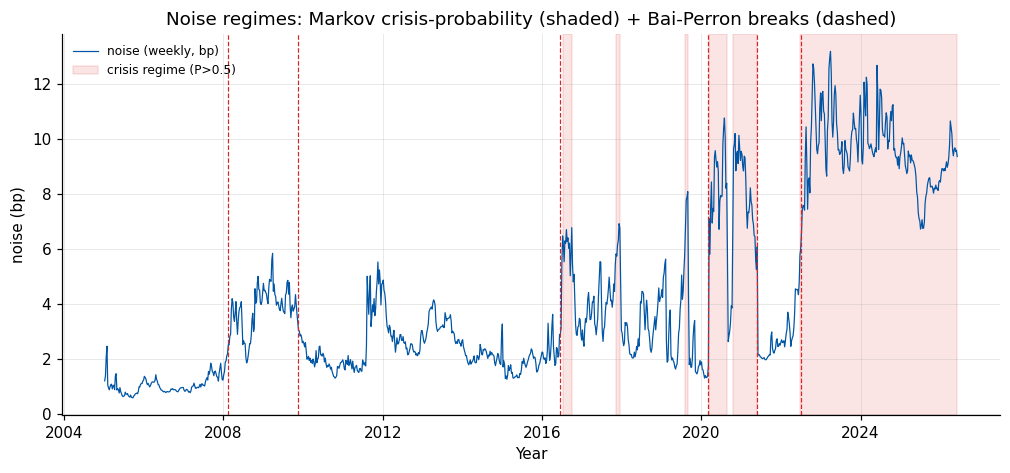

Bai-Perron BIC-selected breaks: ['2008-02-08', '2009-11-13', '2016-06-17', '2020-03-06', '2021-05-28', '2022-07-01']


,start,end,mean_bp
0,2005-01-07,2008-02-08,1.1
1,2008-02-15,2009-11-13,3.8
2,2009-11-20,2016-06-17,2.4
3,2016-06-24,2020-03-06,3.6
4,2020-03-13,2021-05-28,7.8
5,2021-06-04,2022-07-01,2.9
6,2022-07-08,2026-06-05,9.6


In [2]:
bp = rd.bai_perron("noise")
s = mn["series"]
fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(s.index, s.values, lw=.8, color=common.FRANCE_BLUE, label="noise (weekly, bp)")
shade_prob(ax, mn["stress_prob"], label="crisis regime (P>0.5)")
for d in bp["break_dates"]:
    ax.axvline(d, color="tab:red", ls="--", lw=.8)
ax.set(xlabel="Year", ylabel="noise (bp)",
       title="Noise regimes: Markov crisis-probability (shaded) + Bai-Perron breaks (dashed)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
common.save_fig(fig, "study31_noise_regimes.png"); plt.show()
print("Bai-Perron BIC-selected breaks:", [str(d.date()) for d in bp["break_dates"]])
display(bp["segments"])
bp["segments"].to_csv(common.TABLE_DIR / "study31_noise_breaks.csv", index=False)

## 2. The same toolkit on the slope (Study 2) and the political premium (Study 1.1)

Dating the **2022–24 flat/inverted-slope regime** and the **2024+ political-premium regime** with the identical procedure.

.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; 

.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'
.../site-packages/statsmodels\tsa\regime_switching\markov_switching.py:1292: EstimationWarning: Invalid regime transition probabilities estimated in EM iteration; probabilities have been re-scaled to continue estimation.
  warnings.warn('Invalid regime transition probabilities'


  figure -> study31_slope_premium_regimes.png


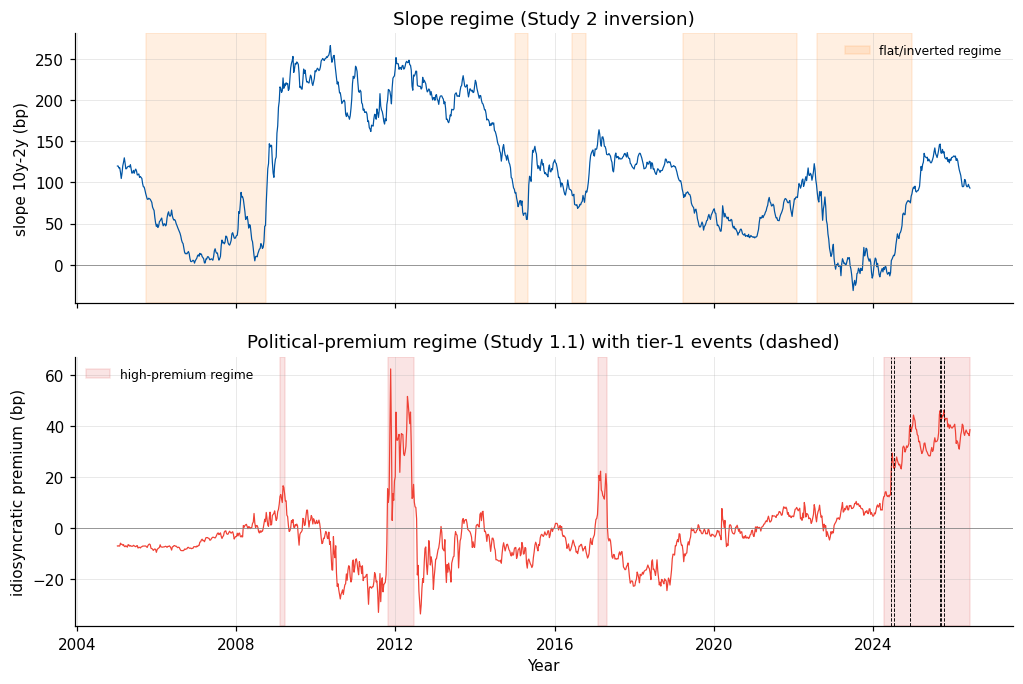

Slope: flat/inverted-regime prob 2022-24 = 0.83 (vs 0.39 before 2022)
Premium: high-premium-regime prob 2024-26 = 0.90 (vs 0.00 in 2019)


In [3]:
ms = rd.markov_switching("slope"); mp = rd.markov_switching("premium")
fig, (axS, axP) = plt.subplots(2, 1, figsize=(11,7), sharex=True)
axS.plot(ms["series"].index, ms["series"].values, lw=.8, color=common.FRANCE_BLUE)
shade_prob(axS, ms["stress_prob"], color="tab:orange", label="flat/inverted regime")
axS.axhline(0, color="grey", lw=.5); axS.set(ylabel="slope 10y-2y (bp)", title="Slope regime (Study 2 inversion)")
axS.legend(frameon=False, fontsize=8, loc="upper right")
axP.plot(mp["series"].index, mp["series"].values, lw=.8, color=common.FRANCE_RED)
shade_prob(axP, mp["stress_prob"], color="tab:red", label="high-premium regime")
for d, info in events.iterrows():
    if info.tier==1 and d>=ms["series"].index.min(): axP.axvline(d, color="k", ls="--", lw=.6)
axP.axhline(0, color="grey", lw=.5); axP.set(xlabel="Year", ylabel="idiosyncratic premium (bp)",
           title="Political-premium regime (Study 1.1) with tier-1 events (dashed)")
axP.legend(frameon=False, fontsize=8, loc="upper left")
common.save_fig(fig, "study31_slope_premium_regimes.png"); plt.show()
print("Slope: flat/inverted-regime prob 2022-24 = %.2f (vs %.2f before 2022)"
      % (ms["stress_prob"].loc['2022':'2024'].mean(), ms["stress_prob"].loc[:'2021'].mean()))
print("Premium: high-premium-regime prob 2024-26 = %.2f (vs %.2f in 2019)"
      % (mp["stress_prob"].loc['2024':'2026'].mean(), mp["stress_prob"].loc['2019'].mean()))

## 3. Corroboration with independent signals (in the spirit of Yi et al.)

Do the dated regimes line up with a **second, independent** information source? Two honest, distinct answers:

* **Political premium ↔ event calendar** — a *hand-coded* signal. Strong alignment: the high-premium regime coincides with the tier-1 political events.
* **Noise dislocation ↔ ECB CISS** — a *market-derived* systemic-stress signal. They only *partly* agree: the post-2022 noise floor is **not** a CISS-stress period, which corroborates the *structural/market-microstructure* reading of Study 3 (free-float/collateral), not a pure systemic-risk one.

Premium regime vs political events: P(stressed) on event weeks = 1.00 vs 0.15 otherwise
Noise regime vs CISS stress: correlation = -0.06, agreement = 46%  (-> the 2022+ floor is structural, not systemic stress)
  figure -> study31_corroboration.png


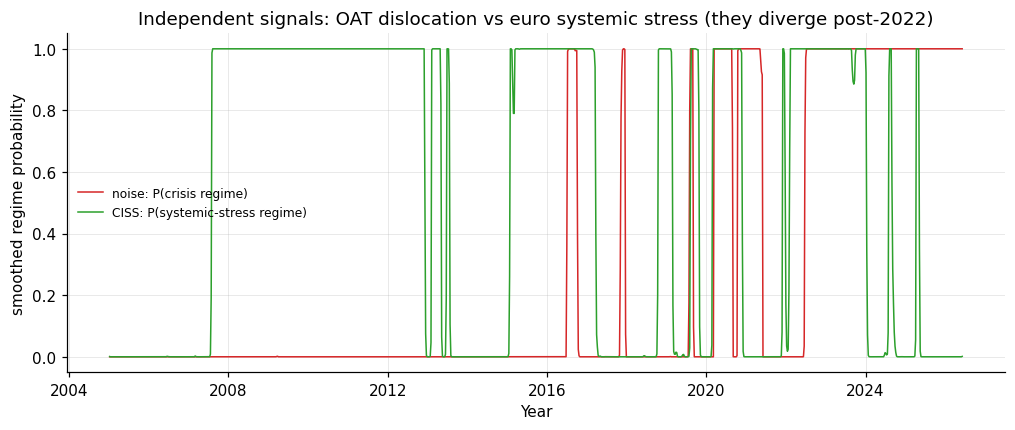

In [4]:
align_ev = rd.event_stress_alignment(mp["stress_prob"], tier=1)
ciss = rd.ciss_stress_prob()
agree = rd.regime_agreement(mn["stress_prob"], ciss)
print("Premium regime vs political events: P(stressed) on event weeks = %.2f vs %.2f otherwise"
      % (align_ev["prob_on_event_weeks"], align_ev["prob_other_weeks"]))
print("Noise regime vs CISS stress: correlation = %.2f, agreement = %.0f%%  (-> the 2022+ floor is structural, not systemic stress)"
      % (agree["correlation"], 100*agree["agreement_share"]))

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(mn["stress_prob"].index, mn["stress_prob"], lw=1, color="tab:red", label="noise: P(crisis regime)")
ax.plot(ciss.index, ciss, lw=1, color="tab:green", label="CISS: P(systemic-stress regime)")
ax.set(xlabel="Year", ylabel="smoothed regime probability",
       title="Independent signals: OAT dislocation vs euro systemic stress (they diverge post-2022)")
ax.legend(frameon=False, fontsize=8)
common.save_fig(fig, "study31_corroboration.png"); plt.show()

## 4. Robustness — structural-stability tests

The CUSUM-of-OLS-residuals test rejects structural stability (p < 0.05) for all three series — an independent confirmation that breaks exist. Multiple random restarts are used for the Markov EM, and the break count is BIC-selected.

In [5]:
cusum = pd.DataFrame({nm: rd.cusum_stability(nm) for nm in ("noise","slope","premium")}).T
display(cusum)
cusum.to_csv(common.TABLE_DIR / "study31_cusum.csv")

,stat,pvalue,stable
noise,12.008,0.0,False
slope,7.723,0.0,False
premium,8.723,0.0,False


### Reading the results

- **The 2022 shift is real and dated.** Markov-switching puts COVID-2020 and the post-2022 period in the high-noise **crisis** regime, with a **return to calm in 2021 in between**; Bai–Perron dates the level shifts to **≈ 6 Mar 2020** (COVID, segment ≈ 8 bp), a **2021 recovery** (≈ 3 bp) and **≈ 1 Jul 2022** (structural floor, ≈ 9.6 bp). This *certifies*, with peer-reviewed methods, Study 3's claim that the 2023–25 floor is a **separate structural regime, not COVID persistence**.
- **The inversion and the political premium are dated too.** The flat/inverted-slope regime concentrates in **2022–24** (Study 2); the high-premium regime switches on in **2024** (Study 1.1) and coincides almost perfectly with the political-event calendar.
- **Corroboration, honestly.** The political-premium regime is confirmed by an independent hand-coded signal (the events). The noise dislocation regime is **only partly** a systemic-stress (CISS) regime — the post-2022 floor is *not* CISS-stress — which is itself evidence for the **structural (free-float/collateral)** interpretation over a pure risk-aversion one.
- **Method vs the motivating paper.** We reach a dated, certified result with standard, peer-reviewed tools on structured data; Yi et al.'s (2026) unstructured-data approach is cited as a complementary avenue, not reproduced — the defensible choice for a thesis chapter.

## References

- Bai, J. & Perron, P. (2003). *Computation and analysis of multiple structural change models.* Journal of Applied Econometrics, 18(1), 1–22.
- Hamilton, J. D. (1989). *A New Approach to the Economic Analysis of Nonstationary Time Series and the Business Cycle.* Econometrica, 57(2), 357–384.
- Ploberger, W. & Krämer, W. (1992). *The CUSUM Test with OLS Residuals.* Econometrica, 60(2), 271–285.
- Truong, C., Oudre, L. & Vayatis, N. (2020). *Selective review of offline change point detection methods.* Signal Processing, 167 (the `ruptures` library).
- Yi, M., Mehra, V., Chen, J. & Cartlidge, J. (2026). *Enhancing Regime Shift Detection Using Unstructured Data: A Study on the Treasury Market.* arXiv (q-fin.CP).
- Grishchenko, O. V., Moraux, F. & Pakulyak, O. (2020). *Fuel up with OATmeals!* The Journal of Finance and Data Science, 6, 49–85.